# Fighting Overfitting — L2 (weight decay), then Dropout + BatchNorm in `MyNN`

In the Last demo, our `MyNN` network overfit: its train accuracy ended up far above its test accuracy.

Here we keep **everything the same** (same widths, same lr=0.1, same 100 epochs, same training loop) and add regularization **in two parts**:
1. **Baseline** — train the original `MyNN` with no regularization.
2. **Part 1 — L2 regularization:** same `MyNN`, we only switch on `weight_decay` in the optimizer. *(changes how we train)*
3. **Part 2 — Dropout + BatchNorm:** we add `nn.Dropout()` and `nn.BatchNorm1d()` **inside the same `MyNN` class**, keeping L2 on. *(changes the model itself)*
4. After **each** model we check train/test accuracy and plot its **per-epoch train vs test curves** next to the previous step. At the end we compare all three **side by side**.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [ ]:
# Set random seeds for reproducibility
torch.manual_seed(42)

In [ ]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## Load the data
Same Fashion-MNIST training file as the GPU demo.

In [ ]:
# Fetches directly (no upload). Note: LFS 'media' host, not 'raw'.
url = 'https://media.githubusercontent.com/media/fpleoni/fashion_mnist/master/fashion-mnist_train.csv'
df = pd.read_csv(url)
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.shape

(60000, 785)

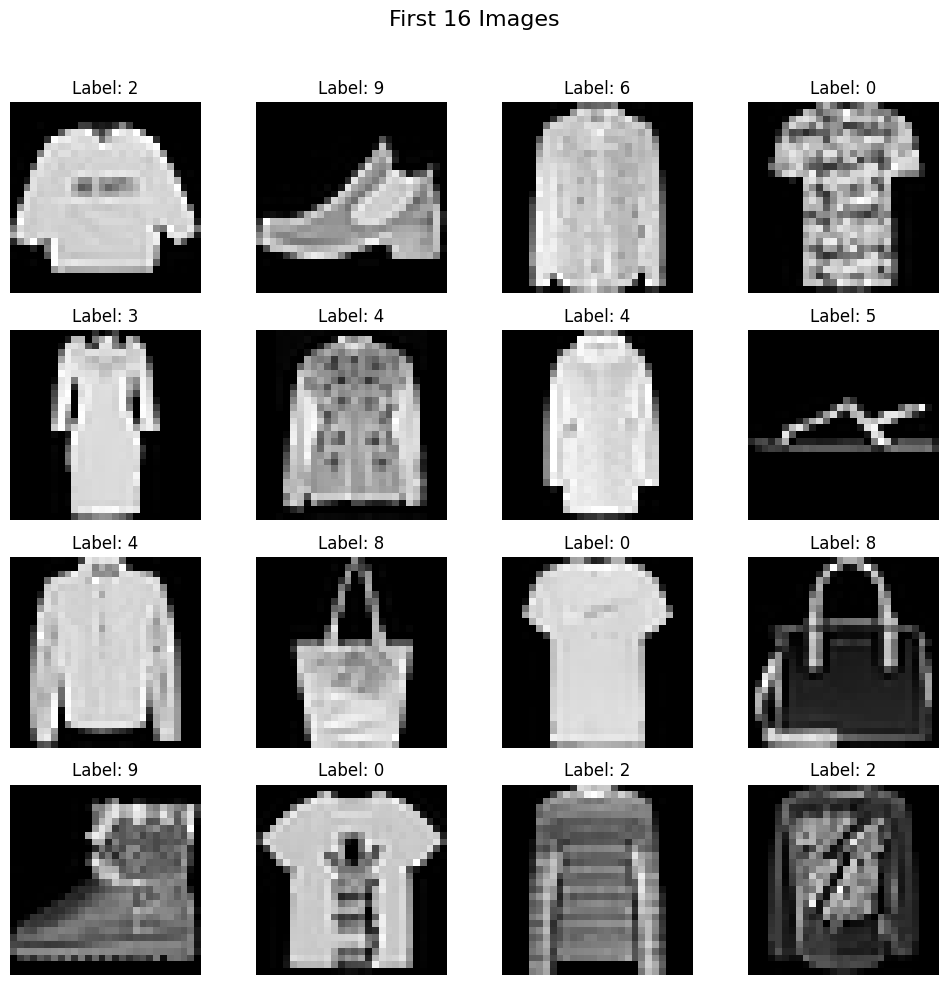

In [ ]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img, cmap='gray')  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()

In [ ]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# scale pixels to 0-1
X_train = X_train/255.0
X_test = X_test/255.0

In [ ]:
class CustomDataset(Dataset):

  def __init__(self, features, labels):
    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]

In [ ]:
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

# bigger batches used ONLY for measuring accuracy/loss every epoch (no gradients -> fast, results identical)
train_eval_loader = DataLoader(train_dataset, batch_size=1024, shuffle=False, pin_memory=True)
test_eval_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False, pin_memory=True)

print(f'train images: {len(train_dataset)} , test images: {len(test_dataset)}')

train images: 48000 , test images: 12000


### Helper: measure loss + accuracy on a dataset
We call this **after every epoch** on both train and test data, so we can plot how the gap grows over time.
It always switches to `model.eval()` so Dropout is off and BatchNorm uses its running statistics.

In [ ]:
def evaluate(model, data_loader):
  model.eval()  # turn off Dropout, use BatchNorm's saved running stats

  total_loss_sum = 0.0      # running sum of loss across ALL images seen so far
  correct_predictions = 0   # running count of correctly classified images
  total_images = 0          # running count of how many images we've checked

  with torch.no_grad():  # we're only measuring performance, not training -> no gradients needed
    for images, true_labels in data_loader:
      images, true_labels = images.to(device), true_labels.to(device)

      predicted_scores = model(images)  # raw class scores for each image (a batch_size x 10 matrix)

      # criterion gives the AVERAGE loss for this batch -> multiply by batch size to get the batch's TOTAL loss
      batch_size = true_labels.shape[0]
      total_loss_sum += criterion(predicted_scores, true_labels).item() * batch_size

      predicted_labels = predicted_scores.argmax(dim=1)  # pick the class with the highest score, per image
      correct_predictions += (predicted_labels == true_labels).sum().item()

      total_images += batch_size

  average_loss = total_loss_sum / total_images
  accuracy = correct_predictions / total_images
  return average_loss, accuracy

### Helper: plot per-epoch train vs test curves
`plot_curves(runs)` draws **one column per model** (top row = accuracy, bottom row = loss):
- **Solid line = train, dashed line = test.** The **shaded band** between them is the overfitting gap.
- All panels in a row share the **same y-axis**, so band widths can be compared directly across models.
- `runs` is a list of `(name, history, color)` — pass one model, or several to compare them side by side.

**Why we compare the average of the last 10 epochs.** With lr=0.1 and batch size 32, accuracy jumps up and down from one epoch to the next — the gap at the final epoch alone can be noticeably higher or lower just by luck. So whenever we *compare* models (gap printouts, table, bar chart, plot titles) we use the **average of the last 10 epochs**, like judging a batter by their average over the last 10 innings instead of only the last one.

In [ ]:
#@title plot_curves functions (click to expand)
N_LAST = 10  # compare models using the average of the last 10 epochs (one noisy epoch can't flip the result)

def avg_last(history, key, n=N_LAST):
  return sum(history[key][-n:]) / n

def plot_curves(runs, acc_ylim=(0.75, 1.0)):
  epoch_range = range(1, len(runs[0][1]['train_acc']) + 1)

  # 2 rows (accuracy, loss) x one column per model; sharey='row' -> same scale across models
  fig, axes = plt.subplots(2, len(runs), figsize=(5.5 * len(runs) + 1, 8),
                           sharex=True, sharey='row', squeeze=False)

  for col, (name, history, color) in enumerate(runs):
    ax_acc, ax_loss = axes[0, col], axes[1, col]

    # accuracy: train vs test, gap shaded
    ax_acc.plot(epoch_range, history['train_acc'], color=color, label='train')
    ax_acc.plot(epoch_range, history['test_acc'], color=color, linestyle='--', label='test')
    ax_acc.fill_between(epoch_range, history['test_acc'], history['train_acc'], color=color, alpha=0.2, label='gap')
    avg_gap = avg_last(history, 'train_acc') - avg_last(history, 'test_acc')
    ax_acc.set_title(f'{name}\ngap (avg last {N_LAST} epochs): {avg_gap:.4f}')
    ax_acc.set_ylim(*acc_ylim)  # fixed range -> accuracy plots look the same scale across the whole notebook
    ax_acc.grid(alpha=0.3)

    # loss: train vs test, gap shaded
    ax_loss.plot(epoch_range, history['train_loss'], color=color, label='train')
    ax_loss.plot(epoch_range, history['test_loss'], color=color, linestyle='--', label='test')
    ax_loss.fill_between(epoch_range, history['train_loss'], history['test_loss'], color=color, alpha=0.2, label='gap')
    ax_loss.set_xlabel('Epoch')
    ax_loss.grid(alpha=0.3)

  axes[0, 0].set_ylabel('Accuracy')
  axes[1, 0].set_ylabel('Cross-entropy loss')
  axes[0, 0].legend(loc='lower right')
  axes[1, 0].legend(loc='upper right')
  fig.suptitle('Train vs Test per epoch', fontsize=14)
  plt.tight_layout()
  plt.show()

  # where did each model's test accuracy peak?
  for name, history, _ in runs:
    best_epoch = max(epoch_range, key=lambda e: history['test_acc'][e - 1])
    print(f"{name.ljust(28)} best test acc {history['test_acc'][best_epoch - 1]:.4f} at epoch {best_epoch:>3} , "
          f"avg test acc (last {N_LAST} epochs) {avg_last(history, 'test_acc'):.4f}")

## Baseline — `MyNN` with no regularization
The same network from the GPU demo. It will overfit.

In [ ]:
class MyNN(nn.Module):

  def __init__(self, num_features):

    super().__init__()
    self.model = nn.Sequential(

        nn.Linear(num_features, 128),
        nn.ReLU(),

        nn.Linear(128, 64),
        nn.ReLU(),

        nn.Linear(64, 10)
    )

  def forward(self, x):

    return self.model(x)


In [ ]:
learning_rate = 0.1
epochs = 100

In [ ]:
# instantiate + train the baseline
torch.manual_seed(42)  # same starting weights + same batch order for both models -> fair comparison
model = MyNN(X_train.shape[1]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

base_history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

for epoch in range(epochs):
  model.train()  # training mode
  total_epoch_loss = 0
  for batch_features, batch_labels in train_loader:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
    outputs = model(batch_features)
    loss = criterion(outputs, batch_labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    total_epoch_loss += loss.item()

  # record train + test performance after this epoch
  train_loss, train_acc = evaluate(model, train_eval_loader)
  test_loss, test_acc = evaluate(model, test_eval_loader)
  base_history['train_loss'].append(train_loss)
  base_history['test_loss'].append(test_loss)
  base_history['train_acc'].append(train_acc)
  base_history['test_acc'].append(test_acc)

  if (epoch + 1) % 10 == 0:
    print(f'Epoch: {epoch + 1} , Loss: {total_epoch_loss/len(train_loader):.4f} , '
          f'train acc: {train_acc:.4f} , test acc: {test_acc:.4f}')

Epoch: 10 , Loss: 0.2764 , train acc: 0.9008 , test acc: 0.8773
Epoch: 20 , Loss: 0.2113 , train acc: 0.9251 , test acc: 0.8848
Epoch: 30 , Loss: 0.1682 , train acc: 0.9239 , test acc: 0.8761
Epoch: 40 , Loss: 0.1410 , train acc: 0.9507 , test acc: 0.8874
Epoch: 50 , Loss: 0.1242 , train acc: 0.9588 , test acc: 0.8868
Epoch: 60 , Loss: 0.1001 , train acc: 0.9638 , test acc: 0.8883
Epoch: 70 , Loss: 0.0859 , train acc: 0.9718 , test acc: 0.8878
Epoch: 80 , Loss: 0.0773 , train acc: 0.9737 , test acc: 0.8884
Epoch: 90 , Loss: 0.0714 , train acc: 0.9745 , test acc: 0.8855
Epoch: 100 , Loss: 0.0631 , train acc: 0.9797 , test acc: 0.8857


Evaluate the baseline on train vs test.

In [ ]:
model.eval()  # evaluation mode

# accuracy on the final trained model (a single snapshot, right now)
_, base_train_acc = evaluate(model, train_eval_loader)
_, base_test_acc = evaluate(model, test_eval_loader)
print(f'final epoch          -> train: {base_train_acc:.4f} , test: {base_test_acc:.4f}')

# accuracy jumps between epochs, so for comparing models we use the average of the last 10 epochs
base_train_avg = avg_last(base_history, 'train_acc')
base_test_avg = avg_last(base_history, 'test_acc')
print(f'avg last {N_LAST} epochs -> train: {base_train_avg:.4f} , test: {base_test_avg:.4f} , gap: {base_train_avg - base_test_avg:.4f}')

final epoch          -> train: 0.9797 , test: 0.8857
avg last 10 epochs -> train: 0.9787 , test: 0.8878 , gap: 0.0909


### Baseline curves — where does memorizing start?
- Does **train** accuracy keep climbing toward 100% while **test** accuracy flattens out? The shaded band keeps widening.
- Look at the loss: does **test loss** stop falling — or even start **rising** — while train loss keeps dropping? That is the model fitting noise in the training set.
- Around which epoch does the test curve stop improving? Every epoch after that mostly improves *train* accuracy only.

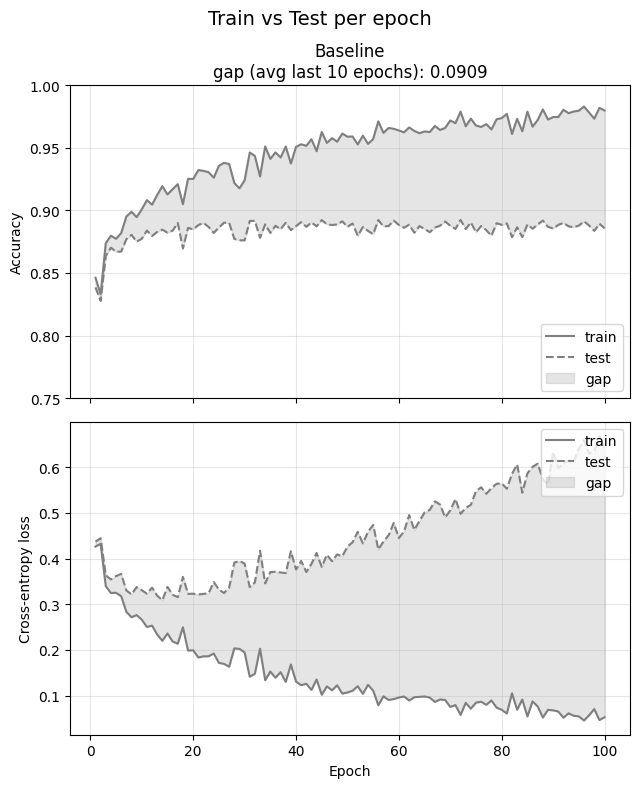

Baseline                     best test acc 0.8923 at epoch  72 , avg test acc (last 10 epochs) 0.8878


In [ ]:
plot_curves([('Baseline', base_history, 'tab:gray')])

## Part 1 — L2 regularization (weight decay)

**Same `MyNN` class, same training loop.** The only change is one argument in the optimizer: `weight_decay`.

L2 regularization adds a penalty for large weights to the loss:

$$\text{Loss} = \text{CrossEntropy} + \frac{\lambda}{2} \sum w^2$$

With SGD, `weight_decay=λ` does exactly this: every step, each weight is also pulled a little towards zero. Large weights let the network fit tiny details (noise) of the training set, so keeping weights small pushes the model towards simpler, smoother decision boundaries.

Question to think about before running: *should train accuracy go up or down? What about the gap?*

In [ ]:
weight_decay = 1e-4
# instantiate + train: SAME baseline MyNN, only weight_decay switched on
torch.manual_seed(42)  # same seed as the baseline -> fair comparison
model = MyNN(X_train.shape[1]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay)  # L2 regularization

l2_history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

for epoch in range(epochs):
  model.train()  # training mode
  total_epoch_loss = 0
  for batch_features, batch_labels in train_loader:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
    outputs = model(batch_features)
    loss = criterion(outputs, batch_labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    total_epoch_loss += loss.item()

  # record train + test performance after this epoch
  train_loss, train_acc = evaluate(model, train_eval_loader)
  test_loss, test_acc = evaluate(model, test_eval_loader)
  l2_history['train_loss'].append(train_loss)
  l2_history['test_loss'].append(test_loss)
  l2_history['train_acc'].append(train_acc)
  l2_history['test_acc'].append(test_acc)

  if (epoch + 1) % 10 == 0:
    print(f'Epoch: {epoch + 1} , Loss: {total_epoch_loss/len(train_loader):.4f} , '
          f'train acc: {train_acc:.4f} , test acc: {test_acc:.4f}')

Epoch: 10 , Loss: 0.2794 , train acc: 0.9034 , test acc: 0.8837
Epoch: 20 , Loss: 0.2217 , train acc: 0.9234 , test acc: 0.8877
Epoch: 30 , Loss: 0.1860 , train acc: 0.9194 , test acc: 0.8744
Epoch: 40 , Loss: 0.1643 , train acc: 0.9392 , test acc: 0.8828
Epoch: 50 , Loss: 0.1472 , train acc: 0.9373 , test acc: 0.8800
Epoch: 60 , Loss: 0.1308 , train acc: 0.9521 , test acc: 0.8838
Epoch: 70 , Loss: 0.1186 , train acc: 0.9566 , test acc: 0.8858
Epoch: 80 , Loss: 0.1119 , train acc: 0.9567 , test acc: 0.8856
Epoch: 90 , Loss: 0.1081 , train acc: 0.9639 , test acc: 0.8893
Epoch: 100 , Loss: 0.1046 , train acc: 0.9647 , test acc: 0.8870


Evaluate the L2 model on train vs test — the same computation as the baseline, done by our `evaluate()` helper.

In [ ]:
_, l2_train_acc = evaluate(model, train_eval_loader)
_, l2_test_acc = evaluate(model, test_eval_loader)
print(f'final epoch          -> train: {l2_train_acc:.4f} , test: {l2_test_acc:.4f}')

l2_train_avg = avg_last(l2_history, 'train_acc')
l2_test_avg = avg_last(l2_history, 'test_acc')
print(f'avg last {N_LAST} epochs -> train: {l2_train_avg:.4f} , test: {l2_test_avg:.4f}')
print(f'gap (avg last {N_LAST} epochs) -> baseline: {base_train_avg - base_test_avg:.4f} , L2: {l2_train_avg - l2_test_avg:.4f}')

final epoch          -> train: 0.9647 , test: 0.8870
avg last 10 epochs -> train: 0.9630 , test: 0.8851
gap (avg last 10 epochs) -> baseline: 0.0909 , L2: 0.0778


### Part 1 curves — what did L2 change? (Baseline vs + L2)
- Is the **orange** band thinner than the **gray** one?
- Did train accuracy drop a little? Did test accuracy change at all?
- Does test loss rise less at the end?
- `weight_decay` is a knob we have to tune: too small and nothing changes; too large and both train **and** test accuracy drop.

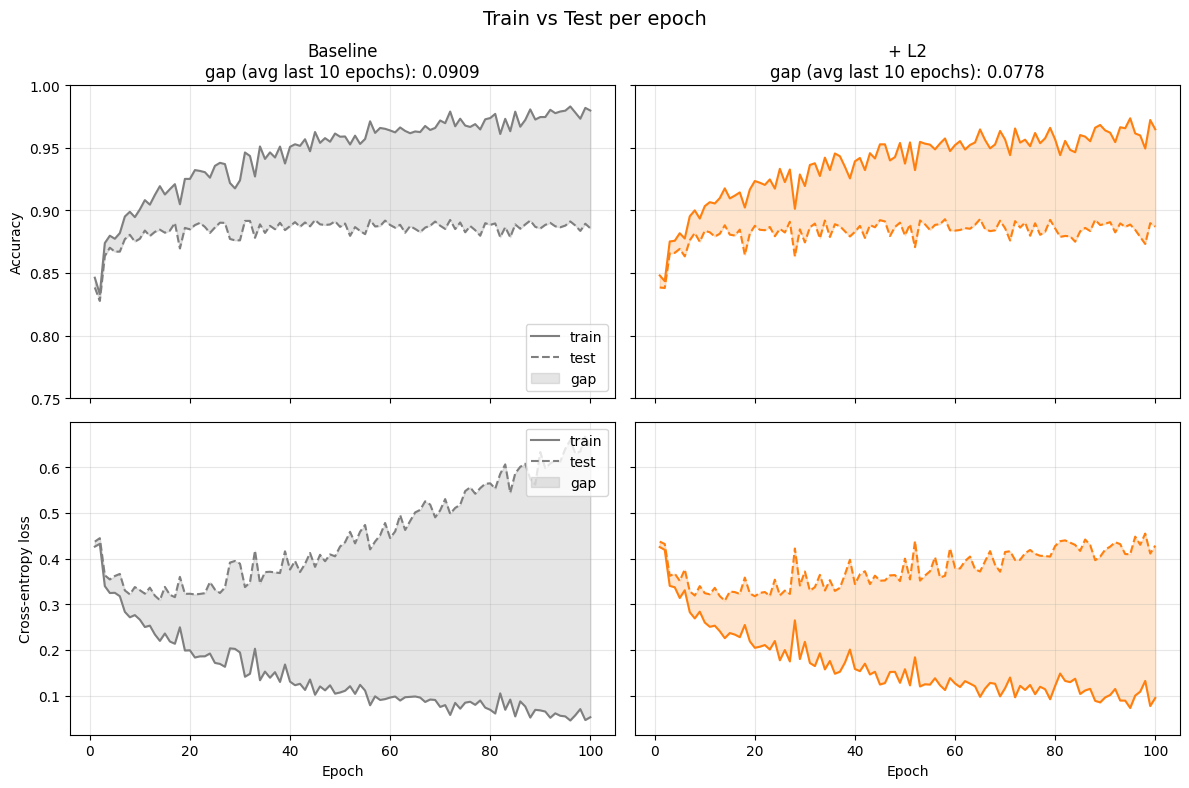

Baseline                     best test acc 0.8923 at epoch  72 , avg test acc (last 10 epochs) 0.8878
+ L2                         best test acc 0.8930 at epoch  65 , avg test acc (last 10 epochs) 0.8851


In [ ]:
plot_curves([
  ('Baseline', base_history, 'tab:gray'),
  ('+ L2', l2_history, 'tab:orange'),
])

## Part 2 — Add `nn.Dropout()` + `nn.BatchNorm1d()` to the **same** `MyNN` (L2 stays on)

Exactly the same class — we insert **BatchNorm** after each `Linear` and **Dropout** after each `ReLU`. The optimizer keeps the **same `weight_decay`** from Part 1, so the only new thing is the two layers.

- **Dropout** randomly switches off 30% of the neurons on every training step, so the network cannot rely on any single neuron to memorize an example. It is only active in `model.train()`; in `model.eval()` all neurons are used.
- **BatchNorm** normalizes each layer's activations using the current mini-batch's mean and std. Its **main job is making training faster and more stable**; the batch-to-batch noise gives a small regularizing effect as a side benefit. In `model.eval()` it uses running averages collected during training.

Of the two, **Dropout does most of the regularizing** here.

**Watch out:** BatchNorm makes the training data *easier* to fit, which partly **cancels** Dropout's effect. That is one reason the dropout rate has to be tuned together with the rest of the model.

In [ ]:
class MyNN(nn.Module):

  def __init__(self, num_features):

    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.BatchNorm1d(128),    # BatchNorm
        nn.ReLU(),
        nn.Dropout(0.3),        # Dropout
        nn.Linear(128, 64),
        nn.BatchNorm1d(64),     # BatchNorm
        nn.ReLU(),
        nn.Dropout(0.3),        # Dropout
        nn.Linear(64, 10)
    )

  def forward(self, x):

    return self.model(x)

In [ ]:
# instantiate + train: MyNN with Dropout + BatchNorm, L2 still on (same loop)
torch.manual_seed(42)  # same seed as the baseline -> fair comparison
model = MyNN(X_train.shape[1]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay)  # L2 kept from Part 1

reg_history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

for epoch in range(epochs):
  model.train()  # training mode (Dropout on, BatchNorm updates)
  total_epoch_loss = 0
  for batch_features, batch_labels in train_loader:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
    outputs = model(batch_features)
    loss = criterion(outputs, batch_labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    total_epoch_loss += loss.item()

  # record train + test performance after this epoch
  train_loss, train_acc = evaluate(model, train_eval_loader)
  test_loss, test_acc = evaluate(model, test_eval_loader)
  reg_history['train_loss'].append(train_loss)
  reg_history['test_loss'].append(test_loss)
  reg_history['train_acc'].append(train_acc)
  reg_history['test_acc'].append(test_acc)

  if (epoch + 1) % 10 == 0:
    print(f'Epoch: {epoch + 1} , Loss: {total_epoch_loss/len(train_loader):.4f} , '
          f'train acc: {train_acc:.4f} , test acc: {test_acc:.4f}')

Epoch: 10 , Loss: 0.3659 , train acc: 0.9030 , test acc: 0.8805
Epoch: 20 , Loss: 0.3255 , train acc: 0.9171 , test acc: 0.8890
Epoch: 30 , Loss: 0.3038 , train acc: 0.9141 , test acc: 0.8828
Epoch: 40 , Loss: 0.2914 , train acc: 0.9339 , test acc: 0.8940
Epoch: 50 , Loss: 0.2803 , train acc: 0.9351 , test acc: 0.8938
Epoch: 60 , Loss: 0.2736 , train acc: 0.9344 , test acc: 0.8898
Epoch: 70 , Loss: 0.2702 , train acc: 0.9377 , test acc: 0.8908
Epoch: 80 , Loss: 0.2641 , train acc: 0.9390 , test acc: 0.8890
Epoch: 90 , Loss: 0.2614 , train acc: 0.9401 , test acc: 0.8894
Epoch: 100 , Loss: 0.2558 , train acc: 0.9468 , test acc: 0.8974


Evaluate the Part 2 model on train vs test.

In [ ]:
_, reg_train_acc = evaluate(model, train_eval_loader)
_, reg_test_acc = evaluate(model, test_eval_loader)
print(f'final epoch          -> train: {reg_train_acc:.4f} , test: {reg_test_acc:.4f}')

reg_train_avg = avg_last(reg_history, 'train_acc')
reg_test_avg = avg_last(reg_history, 'test_acc')
print(f'avg last {N_LAST} epochs -> train: {reg_train_avg:.4f} , test: {reg_test_avg:.4f}')
print(f'gap (avg last {N_LAST} epochs) -> L2: {l2_train_avg - l2_test_avg:.4f} , L2 + Dropout + BatchNorm: {reg_train_avg - reg_test_avg:.4f}')

final epoch          -> train: 0.9468 , test: 0.8974
avg last 10 epochs -> train: 0.9416 , test: 0.8915
gap (avg last 10 epochs) -> L2: 0.0778 , L2 + Dropout + BatchNorm: 0.0501


### Part 2 curves — what did Dropout + BatchNorm add? (+ L2 vs + L2 + Dropout + BatchNorm)
- Is the **blue** band thinner than the **orange** one?
- Train accuracy should be held back more — that is mostly **Dropout** stopping the network from relying on individual neurons.
- Does test loss stay flat instead of rising?
- Is test accuracy any higher, or roughly the same?

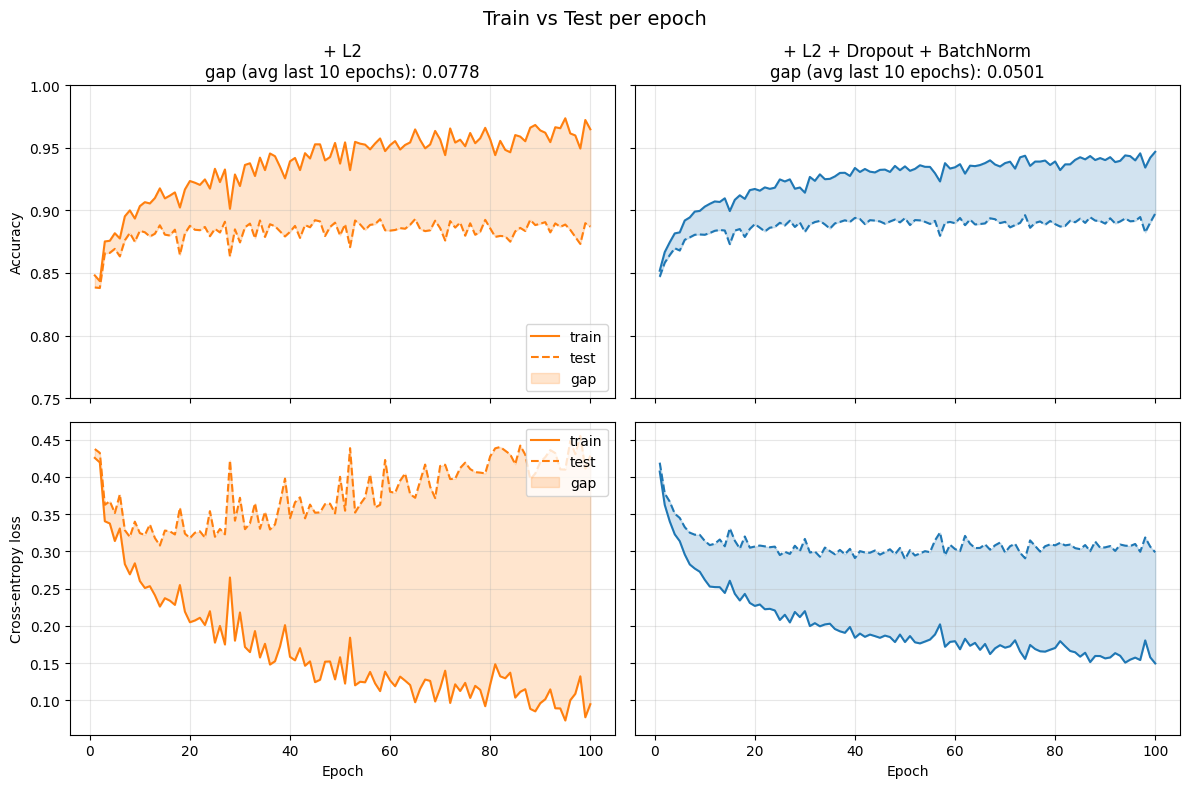

+ L2                         best test acc 0.8930 at epoch  65 , avg test acc (last 10 epochs) 0.8851
+ L2 + Dropout + BatchNorm   best test acc 0.8974 at epoch 100 , avg test acc (last 10 epochs) 0.8915


In [ ]:
plot_curves([
  ('+ L2', l2_history, 'tab:orange'),
  ('+ L2 + Dropout + BatchNorm', reg_history, 'tab:blue'),
])

## All three side by side — how the overfitting gap changes at each step
All numbers below are the **average of the last 10 epochs**.

In [ ]:
results = [
  ('Baseline', base_train_avg, base_test_avg),
  ('+ L2', l2_train_avg, l2_test_avg),
  ('+ L2 + DO + BN', reg_train_avg, reg_test_avg),
]

print(f'(average of last {N_LAST} epochs)')
header = 'Model'.ljust(16) + 'Train'.rjust(8) + 'Test'.rjust(8) + 'Gap'.rjust(8)
print(header)
print('-' * 40)
for name, tr, te in results:
  print(name.ljust(16) + f'{tr:>8.4f}' + f'{te:>8.4f}' + f'{tr - te:>8.4f}')
print('-' * 40)

base_gap = base_train_avg - base_test_avg
l2_gap = l2_train_avg - l2_test_avg
reg_gap = reg_train_avg - reg_test_avg
print(f'Part 1 (L2) changed the gap by:                {l2_gap - base_gap:+.4f}')
print(f'Part 2 (Dropout + BatchNorm) changed it by:    {reg_gap - l2_gap:+.4f}')
print(f'Test accuracy: baseline {base_test_avg:.4f} -> L2 {l2_test_avg:.4f} -> L2 + DO + BN {reg_test_avg:.4f}')

(average of last 10 epochs)
Model              Train    Test     Gap
----------------------------------------
Baseline          0.9787  0.8878  0.0909
+ L2              0.9630  0.8851  0.0778
+ L2 + DO + BN    0.9416  0.8915  0.0501
----------------------------------------
Part 1 (L2) changed the gap by:                -0.0131
Part 2 (Dropout + BatchNorm) changed it by:    -0.0278
Test accuracy: baseline 0.8878 -> L2 0.8851 -> L2 + DO + BN 0.8915


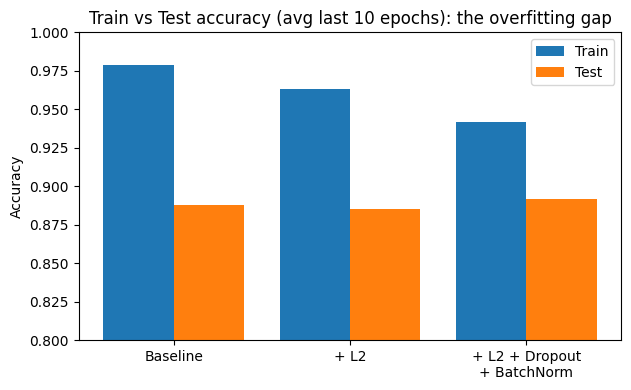

In [ ]:
# Visualise the gap
labels = ['Baseline', '+ L2', '+ L2 + Dropout\n+ BatchNorm']
train_accs = [base_train_avg, l2_train_avg, reg_train_avg]  # average of last 10 epochs
test_accs = [base_test_avg, l2_test_avg, reg_test_avg]
x = range(len(labels))
plt.figure(figsize=(7, 4))
plt.bar([i - 0.2 for i in x], train_accs, width=0.4, label='Train')
plt.bar([i + 0.2 for i in x], test_accs, width=0.4, label='Test')
plt.xticks(list(x), labels)
plt.ylim(0.8, 1.0)  # zoom in: starting at 0 would hide a few-% gap
plt.ylabel('Accuracy')
plt.title(f'Train vs Test accuracy (avg last {N_LAST} epochs): the overfitting gap')
plt.legend()
plt.show()

## All three per-epoch curves — the whole progression
Baseline → + L2 → + L2 + Dropout + BatchNorm, left to right, on the same y-axis. Watch the shaded gap band get thinner as we add regularization.

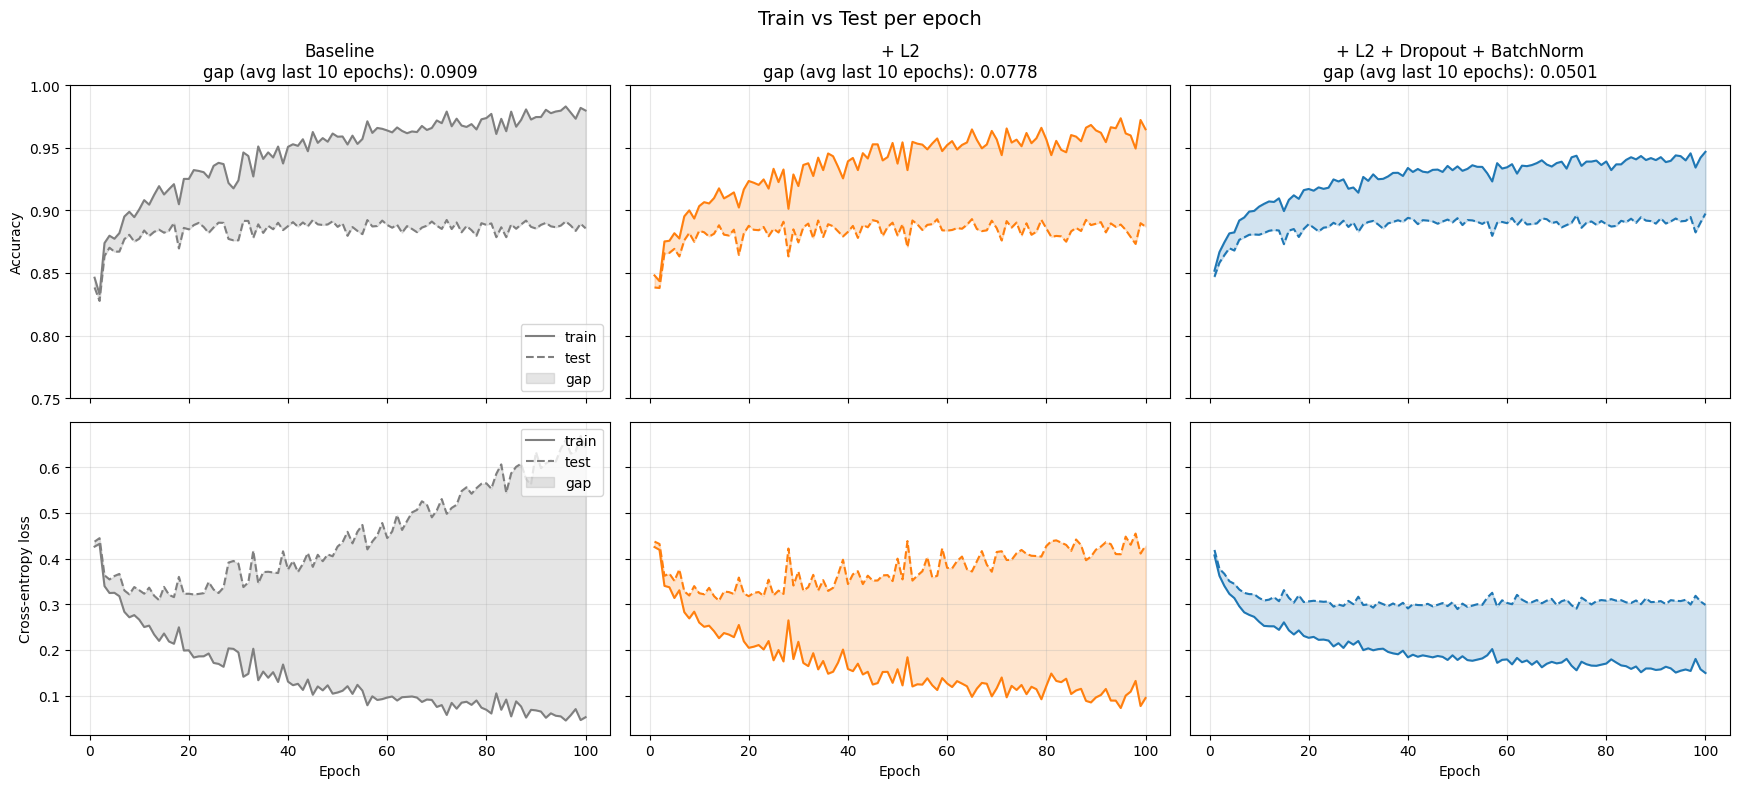

Baseline                     best test acc 0.8923 at epoch  72 , avg test acc (last 10 epochs) 0.8878
+ L2                         best test acc 0.8930 at epoch  65 , avg test acc (last 10 epochs) 0.8851
+ L2 + Dropout + BatchNorm   best test acc 0.8974 at epoch 100 , avg test acc (last 10 epochs) 0.8915


In [ ]:
plot_curves([
  ('Baseline', base_history, 'tab:gray'),
  ('+ L2', l2_history, 'tab:orange'),
  ('+ L2 + Dropout + BatchNorm', reg_history, 'tab:blue'),
])

## Takeaway

- **Baseline:** train accuracy keeps climbing while test accuracy stalls — a wide gap, meaning the network has **memorized** the training set.
- **Part 1 — L2 (weight decay):** one optimizer argument, no change to the model. Penalizing large weights holds train accuracy back, so the gap **shrinks**. How much depends on λ (`weight_decay`) — it is a knob we have to tune, and the right value depends on how much data we have.
- **Part 2 — Dropout + BatchNorm (L2 still on):** the gap shrinks **further**. Dropout does most of this work; BatchNorm mainly makes training faster and more stable — and can even partly cancel Dropout.
- **Notice what happens to test accuracy:** it barely moves (slightly up or slightly down). Regularization mainly **stopped the memorization**; it did not magically add accuracy — a small 2-layer MLP on raw pixels is close to its limit.
- **A smaller gap alone is not the goal.** Too much regularization *underfits*: try a much larger `weight_decay` (for example `1e-2`) as an experiment — the gap almost disappears, but test accuracy drops too. What we want is **good test accuracy with a small gap** — a model whose training score we can trust to reflect how it will perform on new data.
- **Compare averages, not single epochs.** Accuracy jumps around from epoch to epoch, so one epoch's numbers can make a regularizer look better or worse than it really is.